In [ ]:
# Installation de YOLOv8
!pip install ultralytics

# Importation pour vérification
import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.8/107.7 GB disk)


In [ ]:
from ultralytics import YOLO

# Charger le modèle
model = YOLO('yolov8s.pt')

# Faire l'inférence
results = model('https://d29rw3zaldax51.cloudfront.net/assets/images/dashcam-4k-image/Adas-D_features.jpg', conf=0.25)

# Afficher / sauvegarder le résultat
results[0].save(filename='result.jpg')


image 1/1 /content/Adas-D_features.jpg: 416x640 5 cars, 669.2ms
Speed: 17.1ms preprocess, 669.2ms inference, 57.2ms postprocess per image at shape (1, 3, 416, 640)


'result.jpg'

In [ ]:
import json

# Convertir les résultats en JSON
detections = []

for result in results:
    for box in result.boxes:
        detections.append({
            "class_id":    int(box.cls),
            "class_name":  result.names[int(box.cls)],
            "confidence":  round(float(box.conf), 4),
            "bbox": {
                "x1": round(float(box.xyxy[0][0]), 2),
                "y1": round(float(box.xyxy[0][1]), 2),
                "x2": round(float(box.xyxy[0][2]), 2),
                "y2": round(float(box.xyxy[0][3]), 2),
            }
        })

# Sauvegarder en JSON
with open('detections.json', 'w') as f:
    json.dump(detections, f, indent=4)

print(json.dumps(detections, indent=4))


[
    {
        "class_id": 2,
        "class_name": "car",
        "confidence": 0.8559,
        "bbox": {
            "x1": 488.74,
            "y1": 218.05,
            "x2": 605.13,
            "y2": 333.19
        }
    },
    {
        "class_id": 2,
        "class_name": "car",
        "confidence": 0.7908,
        "bbox": {
            "x1": 406.6,
            "y1": 30.76,
            "x2": 523.37,
            "y2": 111.87
        }
    },
    {
        "class_id": 2,
        "class_name": "car",
        "confidence": 0.7149,
        "bbox": {
            "x1": 664.23,
            "y1": 10.29,
            "x2": 751.5,
            "y2": 94.97
        }
    },
    {
        "class_id": 2,
        "class_name": "car",
        "confidence": 0.3911,
        "bbox": {
            "x1": 407.12,
            "y1": 39.13,
            "x2": 484.76,
            "y2": 110.89
        }
    },
    {
        "class_id": 2,
        "class_name": "car",
        "confidence": 0.3059,
        "bbo

In [ ]:
import csv

with open('detections.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['class_id', 'class_name', 'confidence', 'x1', 'y1', 'x2', 'y2'])
    writer.writeheader()
    for d in detections:
        writer.writerow({**{'class_id': d['class_id'], 'class_name': d['class_name'], 'confidence': d['confidence']}, **d['bbox']})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO
import json
import os

source_folder = '/content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit'
output_json = 'toutes_les_detections.json'

#Charger le modèle
model = YOLO('yolov8s.pt')

all_detections = {}

results = model.predict(source=source_folder, conf=0.25, stream=True)

print("Analyse en cours...")

for result in results:
    # Récupérer le nom du fichier image
    file_name = os.path.basename(result.path)
    image_data = []

    # Extraire les détections
    for box in result.boxes:
        image_data.append({
            "class_id":   int(box.cls),
            "class_name": result.names[int(box.cls)],
            "confidence": round(float(box.conf), 4),
            "bbox": [
                round(float(box.xyxy[0][0]), 2),
                round(float(box.xyxy[0][1]), 2),
                round(float(box.xyxy[0][2]), 2),
                round(float(box.xyxy[0][3]), 2)
            ]
        })

    # Stocker dans le dictionnaire principal
    all_detections[file_name] = image_data

# Sauvegarde finale unique
with open(output_json, 'w') as f:
    json.dump(all_detections, f, indent=4)

print(f"Terminé ! Les résultats sont dans {output_json}")

Analyse en cours...

image 1/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000d35d3-41990aa4.jpg: 384x640 5 persons, 2 cars, 1 bus, 4 traffic lights, 415.6ms
image 2/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000d4f89-3bcbe37a.jpg: 384x640 6 cars, 623.6ms
image 3/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000f157f-30b30f5e.jpg: 384x640 3 cars, 2 trucks, 1086.2ms
image 4/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000f157f-37797ff9.jpg: 384x640 3 cars, 452.0ms
image 5/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-2c0ec19d.jpg: 384x640 1 car, 1 fire hydrant, 419.3ms
image 6/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-3f7b0282.jpg: 384x640 (no detections), 408.0ms
image 7/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-4551210e.jpg: 384x640 4 cars, 392.9ms
image 8/250 /content/drive/MyDrive/projet_IA/data/images/cond

In [ ]:
import csv

output_csv = 'detections_globales.csv'

with open(output_csv, 'w', newline='') as f:
    # Définition des colonnes (ajout de 'image_name' pour savoir d'où vient la détection)
    fieldnames = ['image_name', 'class_id', 'class_name', 'confidence', 'x1', 'y1', 'x2', 'y2']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for file_name, detections in all_detections.items():
        for d in detections:
            # On aplatit les données pour le format CSV
            writer.writerow({
                'image_name': file_name,
                'class_id': d['class_id'],
                'class_name': d['class_name'],
                'confidence': d['confidence'],
                'x1': d['bbox'][0],
                'y1': d['bbox'][1],
                'x2': d['bbox'][2],
                'y2': d['bbox'][3]
            })

print(f"Fichier CSV généré avec succès : {output_csv}")

Fichier CSV généré avec succès : detections_globales.csv



image 1/1 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000d35d3-41990aa4.jpg: 384x640 5 persons, 2 cars, 1 bus, 4 traffic lights, 616.3ms
Speed: 3.1ms preprocess, 616.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


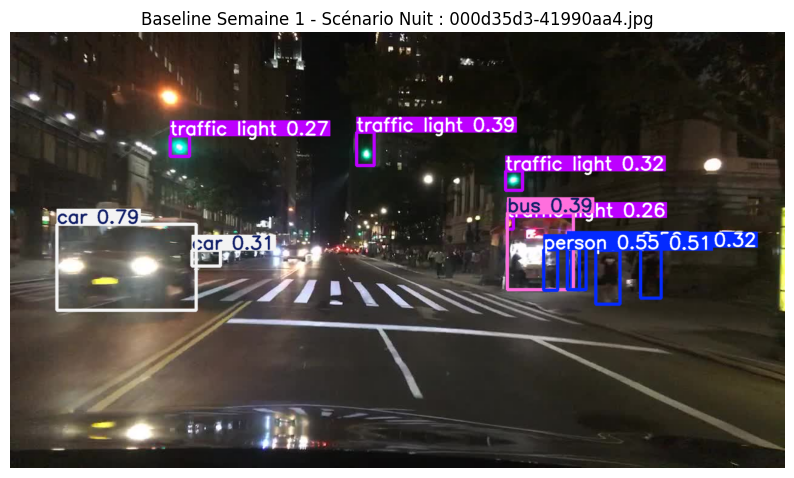

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

nom_image = '000d35d3-41990aa4.jpg'
img_path = f'/content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/{nom_image}'


# Lancer la prédiction
results = model.predict(img_path)

# Tracer et afficher
res_plotted = results[0].plot()
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title(f"Baseline Semaine 1 - Scénario Nuit : {nom_image}")
plt.axis('off')
plt.show()